In [6]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as p
import numpy as np
import flamingo_analysis as fa 
import tangos as db
import flamingo_tangos as ft
import virial_scalings as vs 

# For entropy:
# internal units are Msol^{-2/3} kpc^2 km^2 s^{-2}
# multiply by mu mu_e^{2/3} m_p^(5/3) and convert to get keV cm^2 (mu = 0.59)
internal_to_keV_cm2 = 0.570304


db.init_db('data.db')
db.all_simulations()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[<Simulation("L0200N0360_HYDRO_FIDUCIAL")>,
 <Simulation("L0200N0360_HYDRO_JETS_STRONGER_AGN")>,
 <Simulation("L0200N0360_HYDRO_JETS")>,
 <Simulation("L0200N0360_HYDRO_WEAK_AGN")>,
 <Simulation("L0200N0360_HYDRO_STRONGEST_AGN")>,
 <Simulation("L0200N0720_HYDRO_FIDUCIAL")>]

In [3]:
from matplotlib.colors import LinearSegmentedColormap

n_col = 4
cmap = LinearSegmentedColormap.from_list("red_blue", ["red", "blue"], N=n_col)
colors = [cmap(i/n_col) for i in range(n_col)]

p.rc('axes', prop_cycle=p.cycler('color', colors))

Plotting mass_enclosed profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5
Error in get_labels for all_mass_enclosed: tuple index out of range
Error in get_labels for all_mass_enclosed: tuple index out of range


/Users/app/Science/flamingo/flamingo_tangos_properties/flamingo_analysis.py:120: RuntimeWarning: divide by zero encountered in log
  ln_p = np.log(p)


Error in get_labels for all_mass_enclosed: tuple index out of range
Error in get_labels for all_mass_enclosed: tuple index out of range


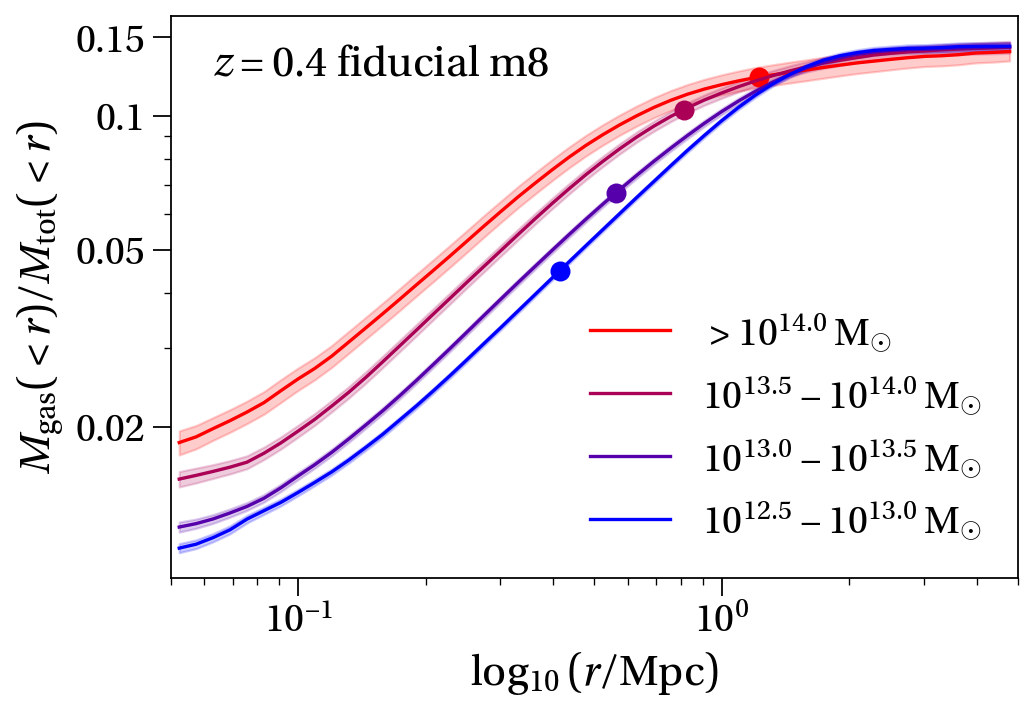

In [4]:
fa.make_profile_plots('mass_enclosed', particle='ratio', tsnum=4, box="L0200N0720_HYDRO_FIDUCIAL", with_legend=True, mark_r200=True, panels=('absolute',))

p.xlabel(r"$\log_{10}(r / {\rm Mpc})$")
p.ylabel(r"$M_{\rm gas}(<r) / M_{\rm tot}(<r)$")
p.yticks([0.02, 0.05, 0.1, 0.15], ['0.02', '0.05', '0.1', '0.15'])
p.xlim(0.05,5.0)
p.text(0.05, 0.95, "$z=0.4$ fiducial m8", transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')
p.title("")
p.savefig('profiles_absolute_with_r200m.pdf', bbox_inches='tight')


### Cross-check plot

Ensure that the baryon density returns to the cosmic mean at large radii

Plotting density_from_mass() profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5


/Users/app/Science/flamingo/flamingo_tangos_properties/flamingo_analysis.py:120: RuntimeWarning: divide by zero encountered in log
  ln_p = np.log(p)


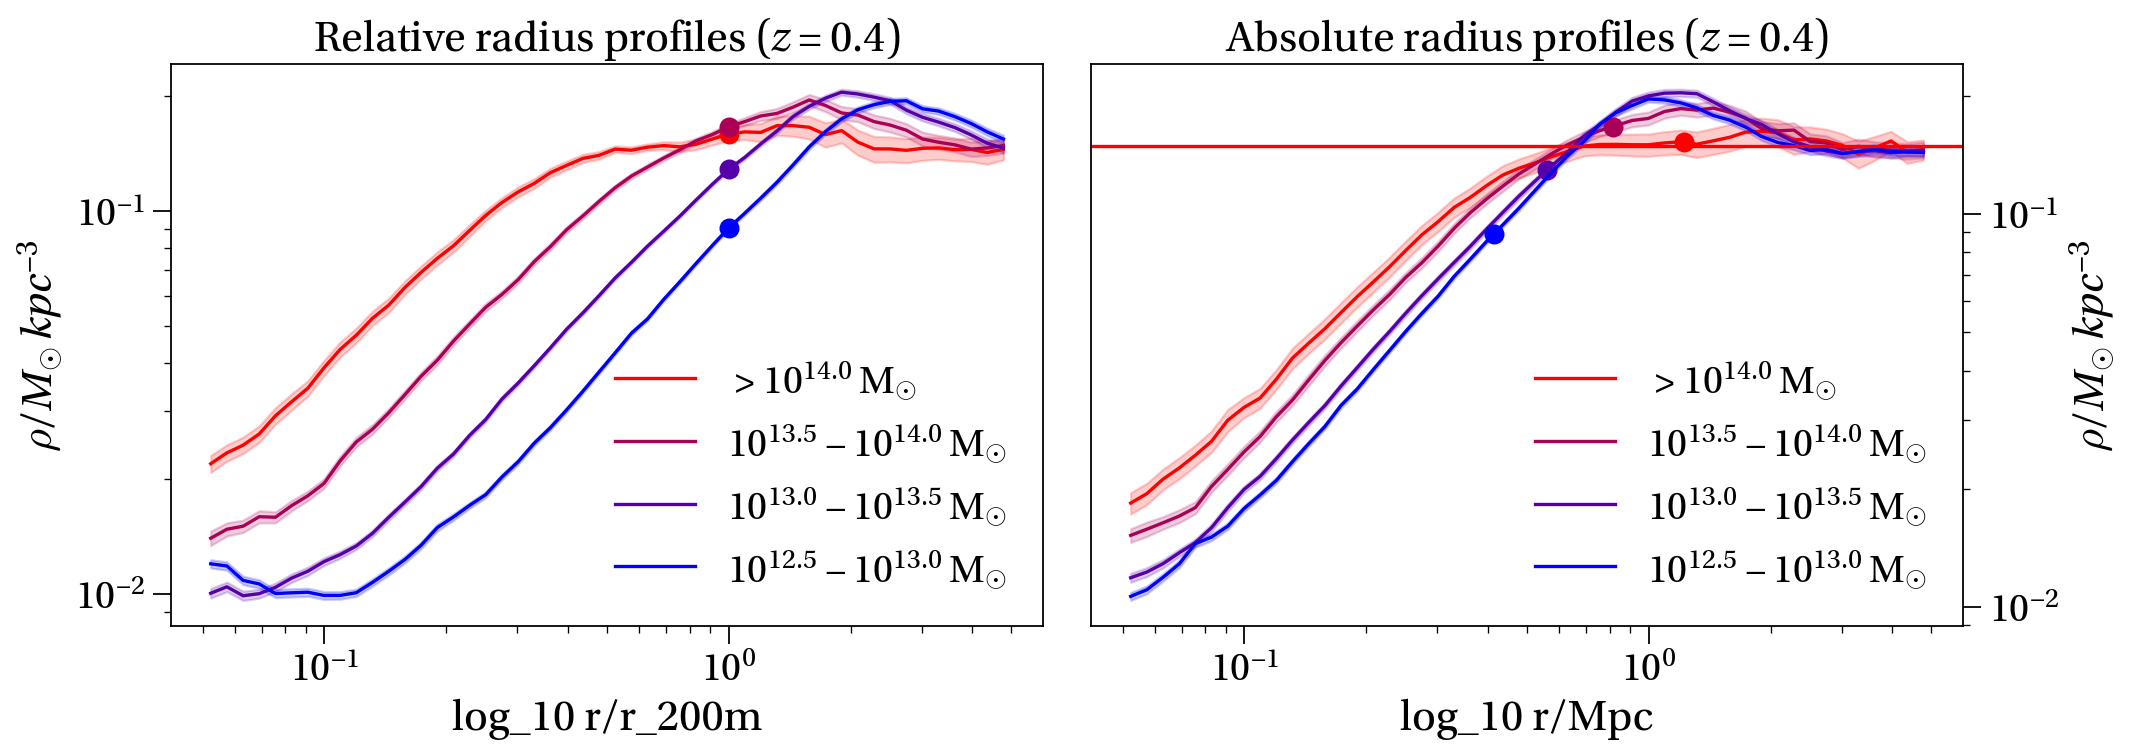

In [5]:
fa.make_profile_plots('density_from_mass()', particle='ratio', tsnum=4, box="L0200N0720_HYDRO_FIDUCIAL", newfig=True, mark_r200=True)
p.axhline(0.14924)

# $\dot{f}_{\rm gas}$ decomposition plot

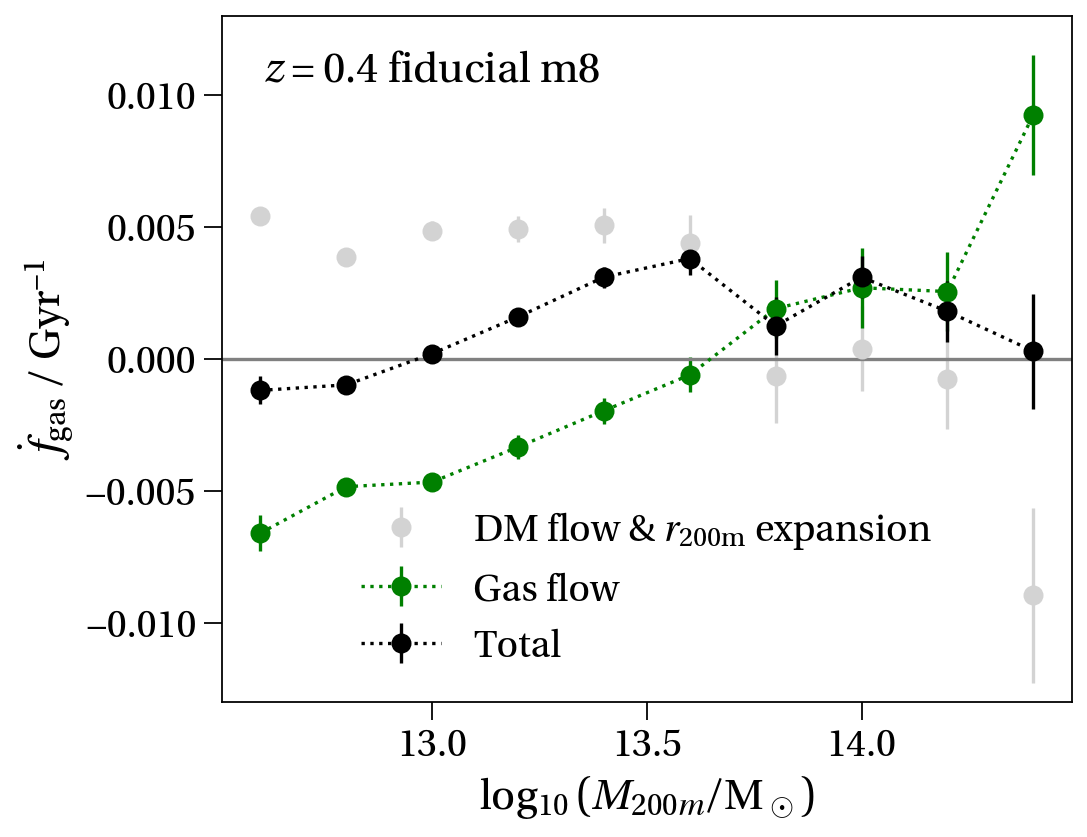

In [7]:
# NB minus sign due to mdot being outflow rather than inflow directed
ts_name = '%720%/%4.hdf5'
gas_term = '-1e9*at(0.0, gas_mdot_r200m_relative)/at(0.0, all_mass_enclosed_r200m_relative)'
dm_term = '1e9*at(0.0, all_mdot_r200m_relative)*at(0.0, gas_mass_enclosed_r200m_relative)/at(0.0, all_mass_enclosed_r200m_relative)**2'
r200_term = '1e9*r200m_dot()*dfgas_dr()'
p.figure()
fa.make_binned_by_mass_plot(f"({dm_term}) + ({r200_term})", plot_kwargs={'color': 'lightgray', 'label': r'DM flow & $r_{\rm 200m}$ expansion'}, ts_name = ts_name, error_range='uncertainty', num_bins=10)
fa.make_binned_by_mass_plot(gas_term, ts_name = ts_name, plot_kwargs={'color': 'green', 'linestyle': ':', 'label': 'Gas flow'}, error_range='uncertainty', num_bins=10)


total = f"({gas_term}) + ({dm_term}) + ({r200_term})"
fa.make_binned_by_mass_plot(total, plot_kwargs={'color': 'black', 'linestyle': ':', 'label': 'Total'}, ts_name = ts_name, error_range='uncertainty', num_bins=10)
p.title("")
p.ylabel(r"$\dot{f}_{\rm gas}$ / Gyr$^{-1}$")
p.xlabel(r"$\log_{10}(M_{200m} / {\rm M_\odot})$")
p.legend(loc='lower center')
p.text(0.05, 0.95, "$z=0.4$ fiducial m8", transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')
p.axhline(0.0, color='gray', linestyle='-')
p.ylim(-0.013, 0.013)
p.savefig('fgas_evolution_breakdown.pdf', bbox_inches='tight')


### Cross-check

Should get qualitatively the same from a discrete time-differencing version of the same terms

/Users/app/Science/flamingo/venv/lib/python3.13/site-packages/tangos/live_calculation/builtin_functions/arithmetic.py:85: RuntimeWarning: divide by zero encountered in divide
  result = op(v1,v2)
/Users/app/Science/flamingo/venv/lib/python3.13/site-packages/tangos/live_calculation/builtin_functions/arithmetic.py:85: RuntimeWarning: invalid value encountered in divide
  result = op(v1,v2)


(-0.013, 0.013)

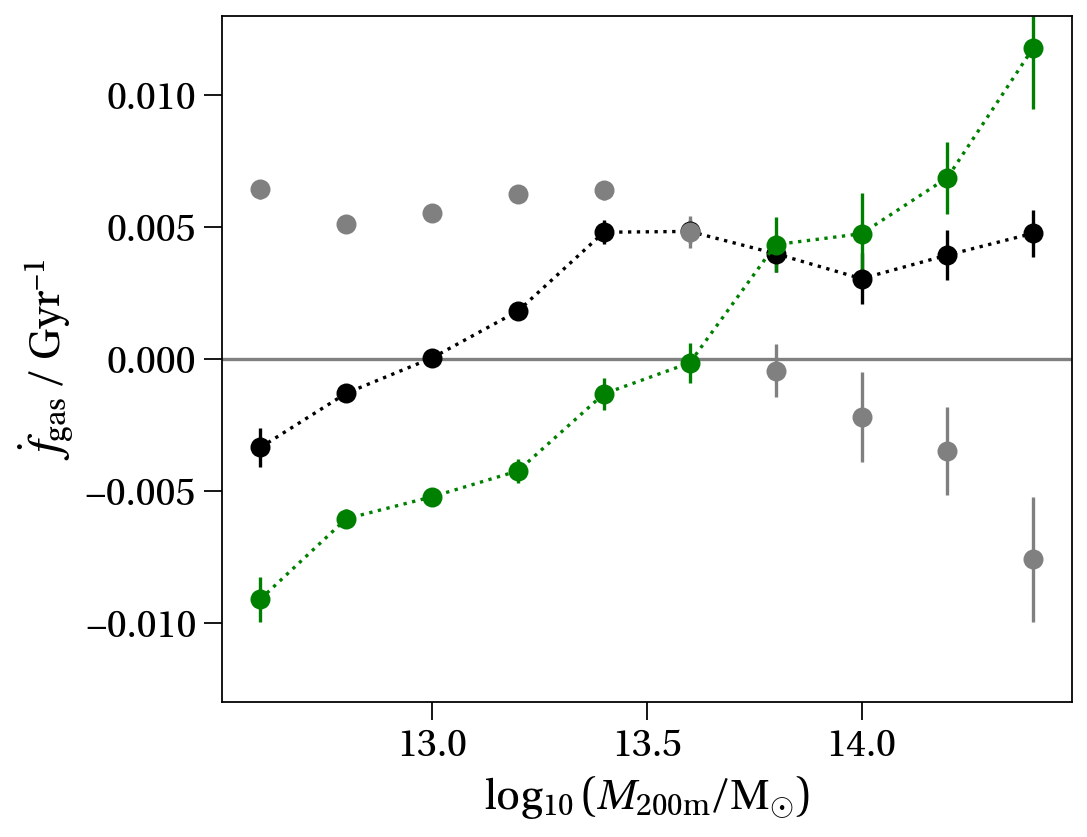

In [8]:
# DISCRETE TIME VERSION of the gas fraction evolution breakdown, as a cross-check

ts_name = '%720%/%4.%'
delta_t_gyr = db.get_timestep(ts_name).time_gyr - db.get_timestep(ts_name).previous.time_gyr

gas_mass_enc = 'at(log10(r200m)-3.0, gas_mass_enclosed)'
delta_gas_mass_enc = f'{gas_mass_enc} - earlier(1).at(later(1).log10(r200m)-3.0, gas_mass_enclosed)'
delta_gas_term = f'({delta_gas_mass_enc}) / at(0.0, dm_mass_enclosed_r200m_relative)'

delta_fgas = f'at(0.0, gas_mass_enclosed_r200m_relative/dm_mass_enclosed_r200m_relative) - earlier(1).at(0.0, gas_mass_enclosed_r200m_relative/dm_mass_enclosed_r200m_relative)'

dm_mass_enc = 'at(log10(r200m)-3.0, dm_mass_enclosed)'
delta_dm_mass_enc = f'earlier(1).at(later(1).log10(r200m)-3.0, dm_mass_enclosed) - {dm_mass_enc}'
delta_dm_term = f'({delta_dm_mass_enc}) * earlier(1).(at(0.0, gas_mass_enclosed_r200m_relative) / at(0.0, dm_mass_enclosed_r200m_relative)) / at(0.0, dm_mass_enclosed_r200m_relative)'

delta_r200_term = 'at(log10(r200m)-3.0, earlier(1).gas_mass_enclosed)/at(log10(r200m)-3.0, earlier(1).dm_mass_enclosed) - at(log10(earlier(1).r200m)-3.0, earlier(1).gas_mass_enclosed)/at(log10(earlier(1).r200m)-3.0, earlier(1).dm_mass_enclosed)'

# all_terms = f'({delta_gas_term}) + ({delta_dm_term} + {delta_r200_term})'  # -- can verify this gives same as delta_fgas, by construction of discrete derivative-like terms

fa.make_binned_by_mass_plot(f'({delta_fgas}) / {delta_t_gyr}', ts_name = ts_name, plot_kwargs={'color': 'black', 'linestyle': ':'}, num_bins = 10, error_range='uncertainty')
fa.make_binned_by_mass_plot(f'({delta_dm_term} + {delta_r200_term}) / {delta_t_gyr}', ts_name = ts_name, plot_kwargs={'color': 'gray'}, num_bins = 10, error_range='uncertainty')
fa.make_binned_by_mass_plot(f'({delta_gas_term}) / {delta_t_gyr}', ts_name = ts_name, plot_kwargs={'color': 'green', 'linestyle': ':'}, num_bins = 10, error_range='uncertainty')

p.title("")
p.ylabel(r'$\dot{f}_{\rm gas}$ / Gyr$^{-1}$')
p.xlabel(r'$\log_{10}(M_{\rm 200m} / {\rm M}_{\odot})$')
p.axhline(0.0, color='gray', linestyle='-')
p.ylim(-0.013, 0.013)

# Main flow rate plot

Plotting mdot_outflow profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5
Plotting mdot_inflow profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5
Plotting mdot_outflow profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5
Plotting mdot_inflow profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5


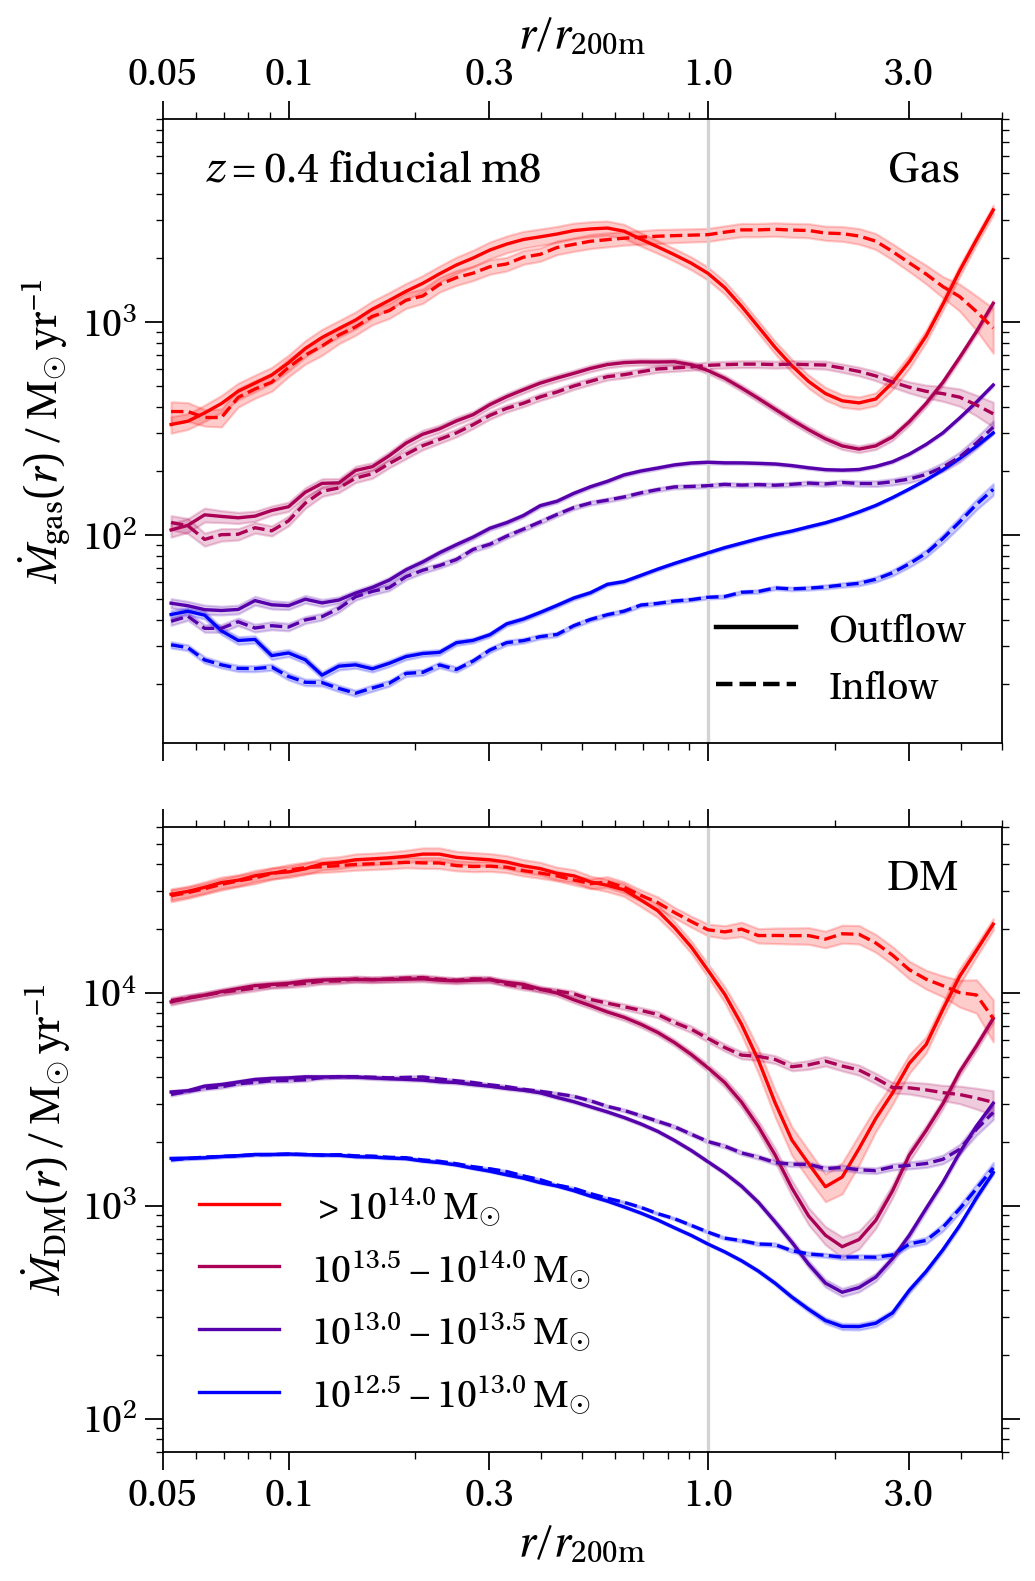

In [9]:
from matplotlib.lines import Line2D

def make_final_flow_plot(particle='gas', tsnum=4):
    p.axvline(1.0, color='lightgray', linestyle='-')

    fa.make_profile_plots('mdot_outflow', particle=particle, tsnum=tsnum, box="L0200N0720_HYDRO_FIDUCIAL", panels=('relative',), newfig=False)

    if particle == 'gas':
        redshift = db.get_timestep(f'%720%/%{tsnum}.hdf5').redshift
        p.text(0.05, 0.95, rf"$z={redshift:.1f}$ fiducial m8", transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')
        p.text(0.95, 0.95, "Gas", transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='right')
        # Create custom legend with black lines
        custom_lines = [Line2D([0], [0], color='black', linewidth=2),
                        Line2D([0], [0], color='black', linewidth=2, linestyle='--')]
        p.legend(custom_lines, ['Outflow', 'Inflow'], loc='lower right')
        p.ylim(0.15*7e1, 0.15*6e4)
    else:
        p.text(0.95, 0.95, "DM", transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='right')
        p.legend(loc='best')
        p.ylim(7e1, 6e4)

    fa.make_profile_plots('mdot_inflow', particle=particle, tsnum=4, box="L0200N0720_HYDRO_FIDUCIAL", 
                        plot_kwargs={'linestyle':'--'}, newfig=False, panels=('relative', ))
    

    p.xlabel(r"$r / r_{\rm 200m}$")

    particle_cased = 'gas' if particle=='gas' else 'DM'
    p.ylabel(r"$\dot{M}_{\rm {"+particle_cased+r"}}(r) \, / \, {\rm M}_{\odot}\,{\rm yr}^{-1}$")
    p.title("")
    p.xticks([0.05, 0.1, 0.3, 1.0, 3.0], ['0.05', '0.1', '0.3', '1.0', '3.0'])

    p.gca().yaxis.set_ticks_position('both')
    
    
    p.xlim(0.05,5.0)


p.figure(figsize=(6.9, 5.2*2))
p.subplot(2,1,1)
make_final_flow_plot(particle='gas', tsnum=4)
p.gca().xaxis.set_ticks_position('top')
p.gca().xaxis.set_label_position('top')
p.gca().xaxis.set_ticks_position('both')
p.subplot(2,1,2)
make_final_flow_plot(particle='dm', tsnum=4)
p.gca().xaxis.set_ticks_position('both')

p.tight_layout()
p.savefig("outflow_inflow_profiles.pdf", bbox_inches='tight')


# Energy rate plot

Text(0.05, 0.95, '$z=0.4$ fiducial m8; $r=50\\,{\\rm kpc}$')

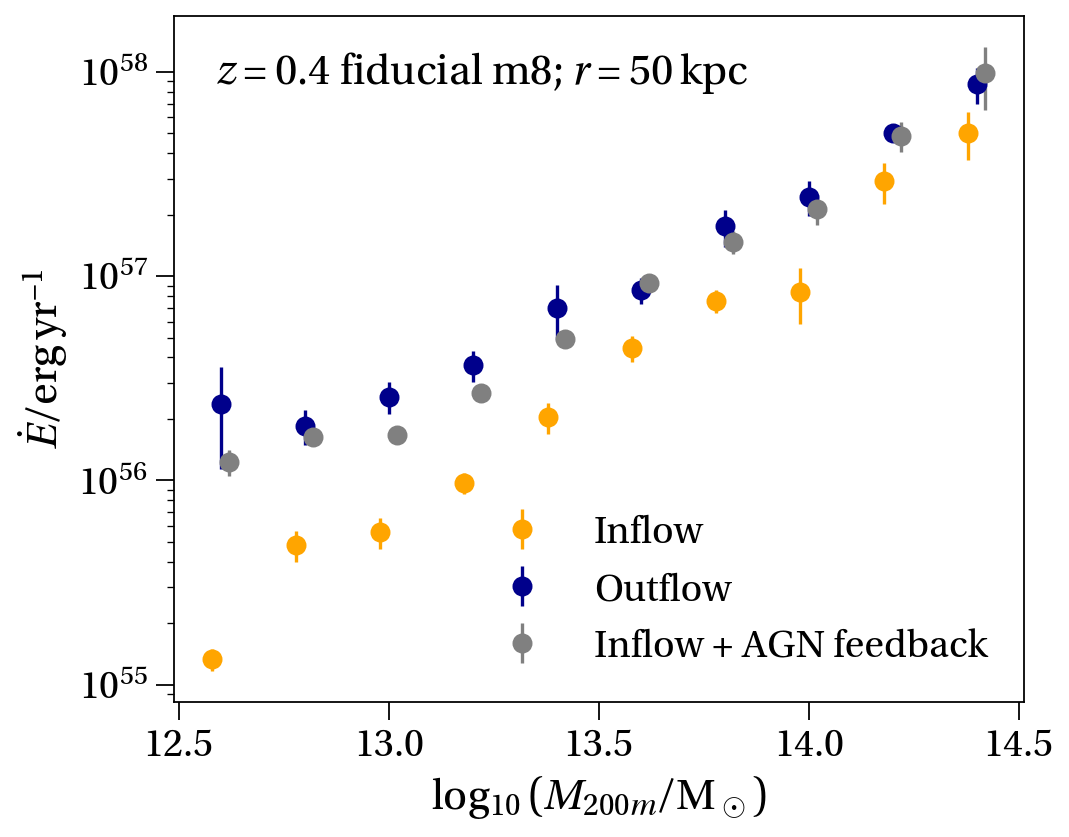

In [10]:
fa.make_binned_by_mass_plot('at(log10(0.05), gas_energy_inflow)',
                            ts_name='%720%/%4.%',
                            plot_kwargs={'color': 'orange'},
                            num_bins = 10, x_offset=-0.02)
fa.make_binned_by_mass_plot('at(log10(0.05), gas_energy_outflow)',
                            ts_name='%720%/%4.%',
                            num_bins=10,
                            plot_kwargs={'color': 'darkblue'}
                            )
fa.make_binned_by_mass_plot('2.7e58*0.0102*InclusiveSphere_30kpc_MostMassiveBlackHoleAccretionRate + at(log10(0.05), gas_energy_inflow)', 
                            ts_name='%720%/%4.%', 
                            plot_kwargs={'color': 'grey'},
                            num_bins=10, x_offset=0.02)
p.semilogy()
p.title("")
p.xlabel(r"$\log_{10}(M_{200m} / {\rm M_\odot})$")
p.ylabel(r"$\dot{E} / {\rm erg\,yr^{-1}}$")
p.legend(['Inflow', 'Outflow', 'Inflow + AGN feedback'], loc='lower right')
p.text(0.05, 0.95, r"$z=0.4$ fiducial m8; $r=50\,{\rm kpc}$", transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')

# Entropy summary plot

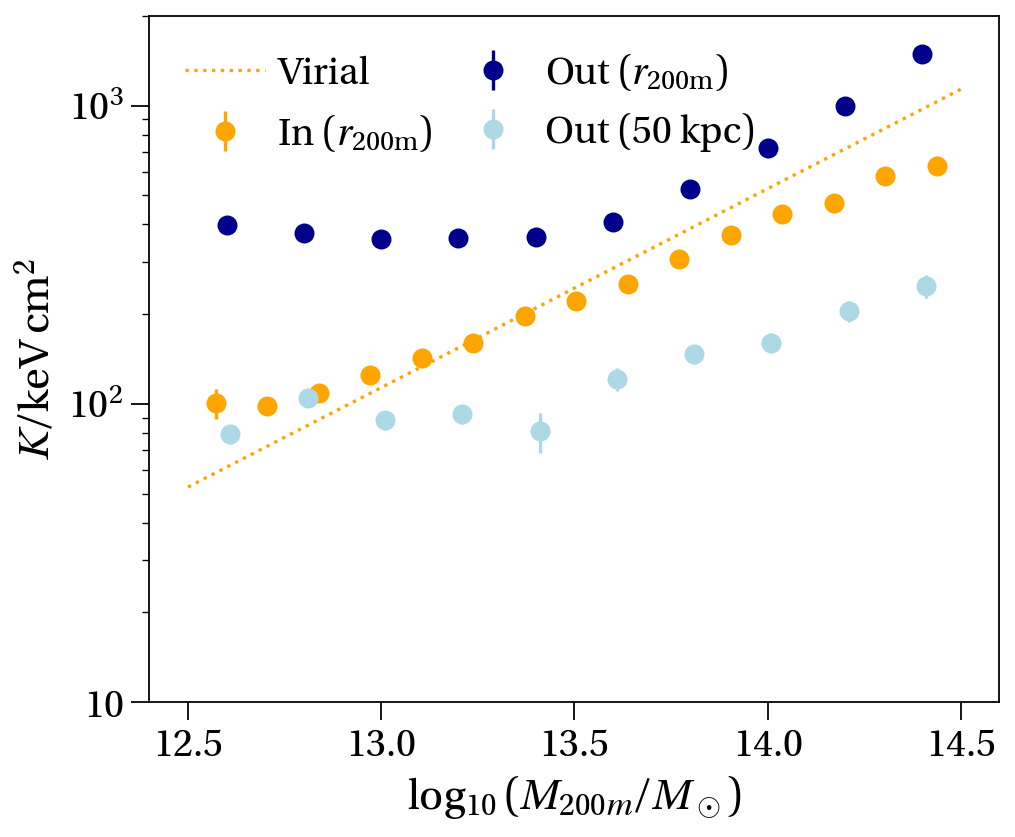

In [7]:
ts = '%720%/%4.%'


fa.make_binned_by_mass_plot(f'{internal_to_keV_cm2} * at(0, gas_entropy_inflow_r200m_relative)', 
                                plot_kwargs={'color': 'orange'},
                                ts_name=ts,
                                weight_property_name=f'at(0, gas_mdot_inflow_r200m_relative)',
                                x_offset=0.005,
                                )
fa.make_binned_by_mass_plot(f'{internal_to_keV_cm2} * at(0, gas_entropy_outflow_r200m_relative)', 
                                plot_kwargs={'color': 'darkblue'},
                                ts_name=ts, num_bins=10,
                                weight_property_name=f'at(0, gas_mdot_outflow_r200m_relative)'
                                )
fa.make_binned_by_mass_plot(f'{internal_to_keV_cm2} * at(-1.3, gas_entropy_outflow)', 
                                plot_kwargs={'color': 'lightblue'},
                                ts_name=ts,
                                weight_property_name=f'at(-1.3, gas_mdot_outflow)',
                                x_offset=0.01, num_bins=10,
                                )

p.xlabel(r"$\log_{10}(M_{200m}/M_\odot)$")
p.ylabel(r"$K / \mathrm{keV\,cm^2}$")
mass_ar = np.linspace(12.5, 14.5, 50)
#entrop_out = vs.outflow_entropy2(10**mass_ar, v_out=250.0, z=0.4)
entrop_in = vs.entropy(10**mass_ar, z=0.4)
#p.plot(mass_ar, entrop_out, color='red', linestyle='--')
p.plot(mass_ar, internal_to_keV_cm2 * entrop_in, color='orange', linestyle=':')

p.title("")
p.legend(['Virial', r'In ($r_{\rm 200m}$)', r'Out ($r_{\rm 200m}$)',
          'Out (50 kpc)'], loc='upper left', ncol=2, columnspacing=0.5, handletextpad=0.3)
p.semilogy()
p.ylim(1e1, 2e3)
p.yticks([10, 100, 1000], ['10', '$10^2$', '$10^3$'])
p.savefig('entropy_inflow_outflow.pdf', bbox_inches='tight')

# Letter entropy plot

In [55]:
def make_plot_at_radius(tsnum, property, at=1.0, relative=True, log=False, weight=False, 
                        boxname=r"%360%FIDUCIAL", use_band=False, error_range='std', norm=1.0):
    log_at = np.log10(at)
    suffix = "_r200m_relative" if relative else ""
    outflow_full_property_name = f'at({log_at}, {property}_outflow{suffix})'
    inflow_full_property_name = f'at({log_at}, {property}_inflow{suffix})'
    if log:
        outflow_full_property_name = f'log10({norm} * abs({outflow_full_property_name}))'
        inflow_full_property_name = f'log10({norm} * abs({inflow_full_property_name}))'
    else:
        outflow_full_property_name = f'{norm} * abs({outflow_full_property_name})'
        inflow_full_property_name = f'{norm} * abs({inflow_full_property_name})'
    fa.make_binned_by_mass_plot(outflow_full_property_name, 
                                plot_kwargs={'color': 'black', 'label': 'Outflow'},
                                ts_name=f"{boxname}/%{tsnum}.hdf5",
                                use_band=use_band, error_range=error_range,
                                weight_property_name=f'at({log_at}, gas_mdot_outflow{suffix})' if weight else None)
    fa.make_binned_by_mass_plot(inflow_full_property_name, 
                                plot_kwargs={'color': 'orange', 'label': 'Inflow'},
                                ts_name=f"{boxname}/%{tsnum}.hdf5",
                                use_band=use_band, error_range=error_range,
                                weight_property_name=f'at({log_at}, gas_mdot_inflow{suffix})' if weight else None,
                                x_offset = 0.02)
    p.xlabel(r"$\log_{10}(M_{200m}/M_\odot)$")
    location_label = f"at {at:.1f} $r_{{200m}}$" if relative else f"{at:.1f} Mpc"
    p.ylabel(rf"{property.replace('_', ' ').title()} at {location_label}")
    p.title("")

def make_virial_entropy_plot(tsnum, at=1.0, relative=True, boxname=r"%360%FIDUCIAL", 
                             use_band=False, error_range='std', weight=False):
    log_at = np.log10(at)
    internal_to_keV_cm2 = 0.570304
    make_plot_at_radius(tsnum, f'gas_entropy', at=at, relative=relative, 
                        boxname=boxname, use_band=use_band, error_range=error_range, weight=weight, norm=internal_to_keV_cm2)
    p.title("")

    z = db.get_timestep(f"{boxname}/%{tsnum}.hdf5").redshift
    K1 = (vs.entropy(10**12.5, z=z))
    K2 = (vs.entropy(10**14.5, z=z))

    p.plot([12.5, 14.5], [K1*internal_to_keV_cm2, K2*internal_to_keV_cm2], color='brown', linestyle='--', label='Virial')
    p.title(f"z={z:.1f}")
    p.legend()
    p.semilogy()

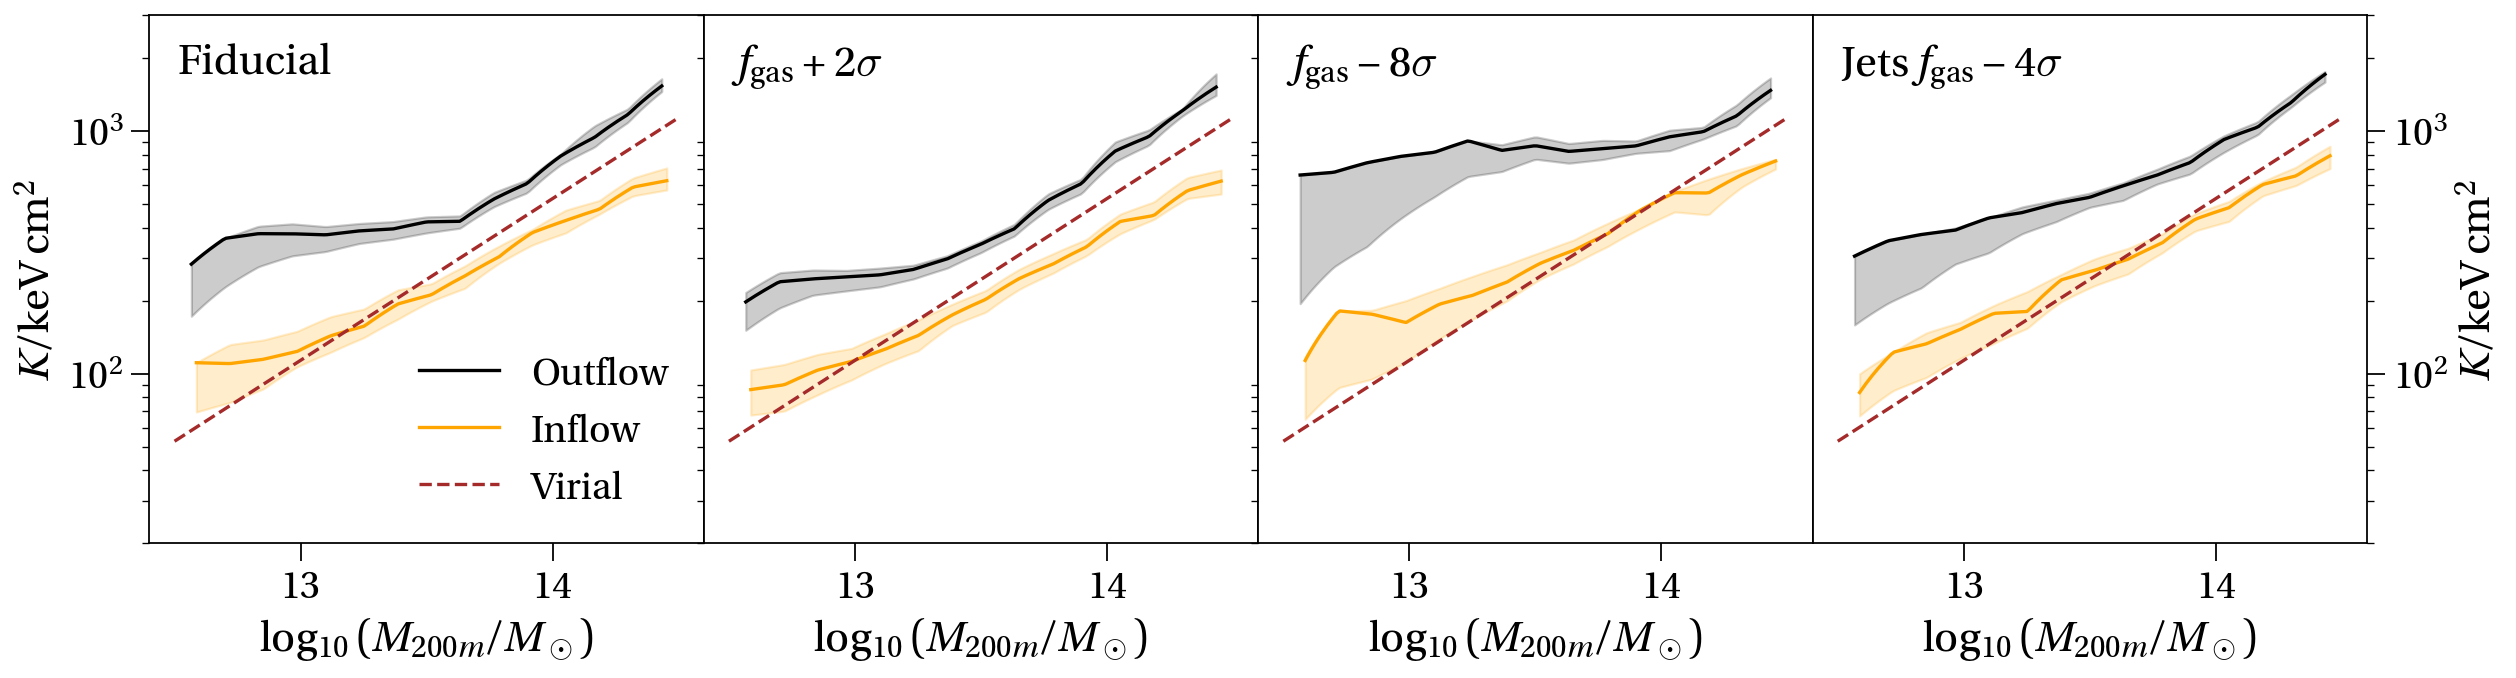

In [58]:
snapnum = 4

redshift = db.get_timestep(f'%720%/%{snapnum}.hdf5').redshift

v_entrop_kwargs = {'relative': True, 
                   'error_range': (32, 68), 
                   'weight': True,
                   'use_band': True}
ylim = (20., 3e3)
ylabel = r"$K/{\rm keV\,cm^2}$"

p.figure(figsize=(18,4))


p.subplot(141)

make_virial_entropy_plot(snapnum, at=1.0, **v_entrop_kwargs)
p.ylim(ylim)
p.ylabel(ylabel)
p.title("")
p.text(0.05, 0.95, fr"Fiducial",
      transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')

p.subplot(142)
make_virial_entropy_plot(snapnum, at=1.0, **v_entrop_kwargs, boxname='%WEAK%')
p.ylim(ylim)
p.ylabel("")
p.title("")
fa.remove_existing_legend()
p.gca().set_yticks([])
p.text(0.05, 0.95, r"$f_{\rm gas} + 2 \sigma$",
      transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')

p.subplot(143)
make_virial_entropy_plot(snapnum, at=1.0, **v_entrop_kwargs, boxname='%STRONGEST%')
p.ylim(ylim)
p.ylabel("")
p.title("")
fa.remove_existing_legend()
p.gca().set_yticks([])
p.text(0.05, 0.95, r"$f_{\rm gas} - 8 \sigma$",
      transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')

p.subplot(144)
make_virial_entropy_plot(snapnum, at=1.0, **v_entrop_kwargs, boxname='%JETS_STRONGER%')
p.ylim(ylim)
p.ylabel(ylabel)
p.title("")
p.gca().yaxis.set_label_position('right')
p.gca().yaxis.set_ticks_position('right')
fa.remove_existing_legend()
p.text(0.05, 0.95, r"Jets $f_{\rm gas} - 4 \sigma$",
      transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')


"""
p.subplot(412)
make_virial_entropy_plot(snapnum, at=1.0, **v_entrop_kwargs)
p.title("")
p.title("")
p.gca().xaxis.set_ticks_position('top')
p.gca().xaxis.set_label_position('top')
p.ylim(ylim)
p.ylabel(ylabel)
p.gca().yaxis.set_ticks_position('right')
p.gca().yaxis.set_label_position('right')
fa.remove_existing_legend()
p.text(0.05, 0.95, r"$r=r_{200m}$", 
      transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')

p.subplot(223)
make_virial_entropy_plot(snapnum, at=0.2, **v_entrop_kwargs, boxname="%360%STRONGEST%")
p.title("")
fa.remove_existing_legend()
p.ylabel(ylabel)
p.ylim(ylim)
p.text(0.05, 0.95, fr"$z={redshift:.1f}$ $f_{{\rm gas}} - 8\sigma$ m9; $r=0.2\, r_{{200m}}$",
      transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')

p.subplot(224)
make_virial_entropy_plot(snapnum, at=1.0, **v_entrop_kwargs, boxname="%360%STRONGEST%")
p.ylabel(ylabel)
p.ylim(ylim)
p.gca().yaxis.set_ticks_position('right')
p.gca().yaxis.set_label_position('right')
p.title("")
p.text(0.05, 0.95, r"$r=r_{200m}$", 
      transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')

fa.remove_existing_legend()
"""

p.subplots_adjust(hspace=0, wspace=0)
p.savefig('entropy_letter_fig.pdf', bbox_inches='tight')

[]

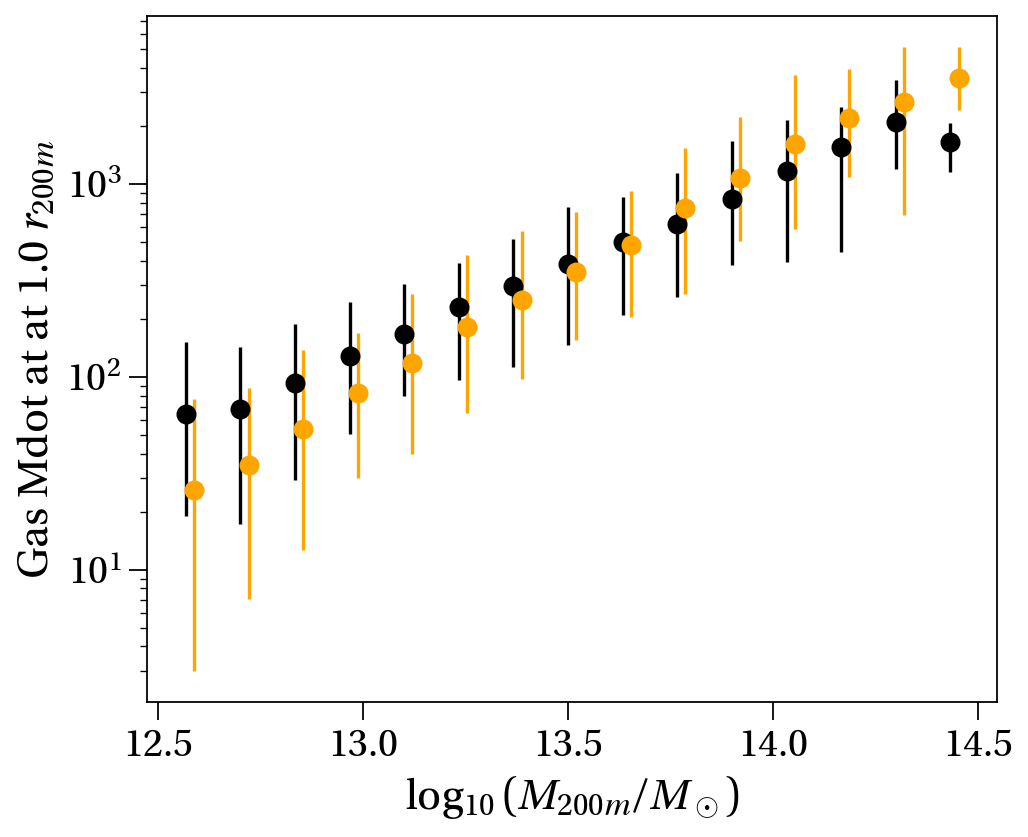

In [60]:
make_plot_at_radius(4, property='gas_mdot', at=1.0, relative=True, error_range=(5,95), boxname="%360%WEAK%")
p.semilogy()